   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


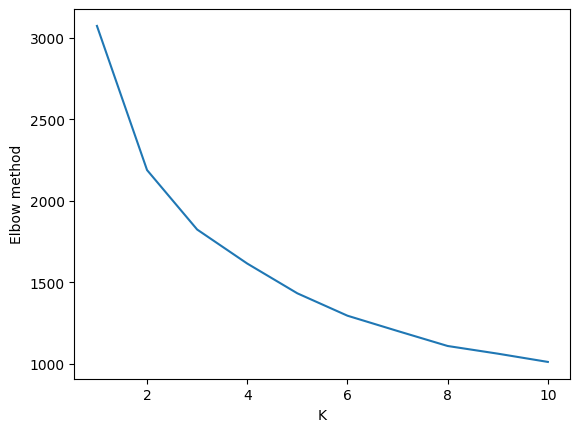

k=2, score=0.27843333963764233
k=3, score=0.27254316095206055
k=4, score=0.2537106024220577
k=5, score=0.21389763978362708
k=6, score=0.2138604726700136
k=7, score=0.20837884010215935
k=8, score=0.22064212016204132
k=9, score=0.20272804676547573
k=10, score=0.20044003653411324
cluster
2    105.097195
1    132.516556
0    144.350635
Name: Glucose, dtype: float64
   cluster Health_Status
0        1          Risk
1        2       Healthy
2        2       Healthy
3        2       Healthy
4        2       Healthy
               Pregnancies     Glucose  ...   Outcome  cluster
Health_Status                           ...                   
Critical          4.041096  144.350635  ...  0.579909      0.0
Healthy           2.811558  105.097195  ...  0.173367      2.0
Risk              6.284768  132.516556  ...  0.476821      1.0

[3 rows x 10 columns]


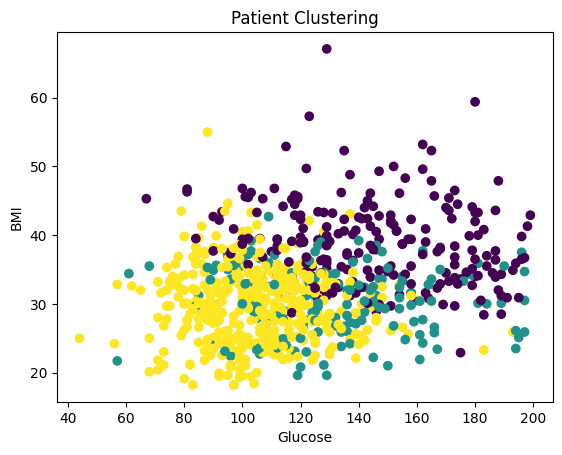

In [6]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

print(df.head())
print(df.columns)

cols = ['Glucose', 'BloodPressure', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].mean())


x = df[['Glucose','BMI', 'BloodPressure', 'Age']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("Elbow method")
plt.show()

from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, score={score}")

    ##train model
    
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
    
df['cluster'] = labels

cluster_means = df.groupby('cluster')['Glucose'].mean().sort_values()

print(cluster_means)

mapping = {
    cluster_means.index[0]: "Healthy",
    cluster_means.index[1]: "Risk",
    cluster_means.index[2]: "Critical"
}

df['Health_Status'] = df['cluster'].map(mapping)

# Check result
print(df[['cluster', 'Health_Status']].head())

# Analyze
print(df.groupby('Health_Status').mean())

# print(df.groupby('cluster').mean())




plt.scatter(df['Glucose'], df['BMI'], c=df['cluster'])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Patient Clustering")
plt.show()


